# Stats

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import t
import seaborn as sns

In [2]:
def power_law(t, theta, init_area=28.56):
    t_0 = (init_area / theta[0])**(1/theta[1])
    return theta[0] * (t + t_0)**theta[1]

def power_law_gradient(t, theta, init_area=28.56):
    G = np.zeros((len(t), 2))
    G[:, 0] = t * (t + (init_area / theta[0])**(1 / theta[1]))**(theta[1] - 1)
    G[:, 1] = theta[0] * ((t + (init_area / theta[0])**(1 / theta[1]))**theta[1] * np.log(t + (init_area / theta[0])**(1 / theta[1]))
                    - np.log(init_area / theta[0]) * (init_area / theta[0])**(1 / theta[1]) * (t + (init_area / theta[0])**(1 / theta[1]))**(theta[1] - 1) / theta[1])
    return G


In [3]:
def fitting(t_data, y_mean, y_sem, init_area=28.56):
    def weighted_residuals(theta):
        return (y_mean - power_law(t_data, theta, init_area)) / y_sem
    return least_squares(weighted_residuals, [12, -0.25])

In [4]:
def confidence_band(t_fit, optim_res, init_area=28.56):
  n = len(optim_res.fun)
  J = optim_res.jac       # shape (n, 2)

  rss = np.sum(optim_res.fun**2)   # weighted RSS
  sigma2_hat = rss / (n - 2)      # unbiased variance estimator

  Cov_theta = sigma2_hat * np.linalg.inv(J.T @ J)

  alpha = 0.05
  tval = t.ppf(1 - alpha/2, n - 2)

  y_fit = power_law(t_fit, optim_res.x, init_area)
  G = power_law_gradient(t_fit, optim_res.x, init_area)

  y_var = np.einsum("ij,jk,ik->i", G, Cov_theta, G)
  y_se  = np.sqrt(y_var)

  y_lower = y_fit - tval * y_se
  y_upper = y_fit + tval * y_se

  return y_fit, y_lower, y_upper

In [5]:
def prediction_band(t_fit, optim_res, W, init_area=28.56):
  n = len(optim_res.fun)
  J = optim_res.jac       # shape (n, 2)

  rss = np.sum(optim_res.fun**2)   # weighted RSS
  sigma2_hat = rss / (n - 2)      # unbiased variance estimator

  Cov_theta = sigma2_hat * np.linalg.inv(J.T @ J)

  alpha = 0.05
  tval = t.ppf(1 - alpha/2, n - 2)

  y_fit = power_law(t_fit, optim_res.x, init_area)
  G = power_law_gradient(t_fit, optim_res.x, init_area)

  y_var = np.einsum("ij,jk,ik->i", G, Cov_theta, G)  
  y_var_pred = y_var + sigma2_hat
  y_se_pred = np.sqrt(y_var_pred)

  y_lower = y_fit - tval * y_se_pred
  y_upper = y_fit + tval * y_se_pred

  return y_fit, y_lower, y_upper

Data (mean + std) for "steady state" experiment

In [6]:
# time points
t_dataA = np.array([4.25, 25, 28.5, 32.5, 48, 51.75, 72, 79.5, 96, 103.5])

# mean of 5 samples at each time
y_meanA = np.array([8.2668, 4.9254, 4.5688, 4.5752, 4.0178, 3.9404, 3.6374, 3.632, 3.432, 3.4046])

# sample standard deviation of the 5 samples
y_stdA = np.array([0.515392763, 0.231599439, 0.197482151, 0.250617637, 0.220541833, 0.248538327, 0.176351354, 0.142592076, 0.192494156, 0.156575222])

n_rep = 5
y_semA = y_stdA / np.sqrt(n_rep)  # standard error of the mean

Data (mean + std) for "pilot study 2" experiment

In [8]:
# time points
t_dataB = np.array([3.5, 5.75, 7.5, 24, 30, 38, 48])

# mean of 5 samples at each time
y_meanB = np.array([17.79526, 12.7622, 9.7465, 6.3022, 5.4894, 5.7354, 4.6958])

# sample standard deviation of the 5 samples
y_stdB = np.array([0.755228964, 0.748305887, 0.583023441, 0.554382269, 0.300793617, 0.448937412, 0.291725385])

y_semB = y_stdB / np.array([5, 5, 4, 5, 5, 5, 5])  # standard error of the mean

In [24]:
optim_res = fitting(t_data, y_mean, y_sem)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_data[-1], 0.1)
y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

a = 42.144
b = -0.573


a = 11.844
b = -0.274
720 720
a = 42.144
b = -0.573


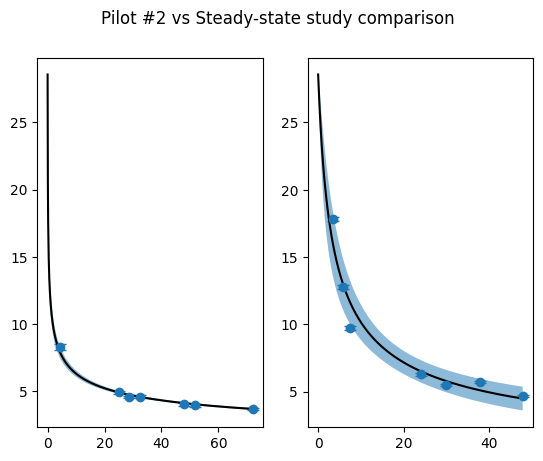

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Pilot #2 vs Steady-state study comparison')

ax1.errorbar(
    t_dataA[:7], y_meanA[:7], yerr=y_semA[:7],
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_dataA, y_meanA, y_semA)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_dataA[6], 0.1)
y_fitA, y_lower, y_upper = confidence_band(t_fit, optim_res)

print(len(t_fit), len(y_fitA))

ax1.plot(t_fit, y_fitA, 'k-', label='Weighted fit')
ax1.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# ax1.xlabel('Time')
# ax1.ylabel('Measurement')

ax2.errorbar(
    t_dataB, y_meanB, yerr=y_semB,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_dataB, y_meanB, y_semB)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_dataB[-1], 0.1)
y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

ax2.plot(t_fit, y_fit, 'k-', label='Weighted fit')
ax2.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# ax2.xlabel('Time')
# ax2.ylabel('Measurement')
# plt.legend()
# plt.tight_layout()
plt.show()

theta =  [35.57076746 -0.44311436]
a = 33.381
b = -0.391


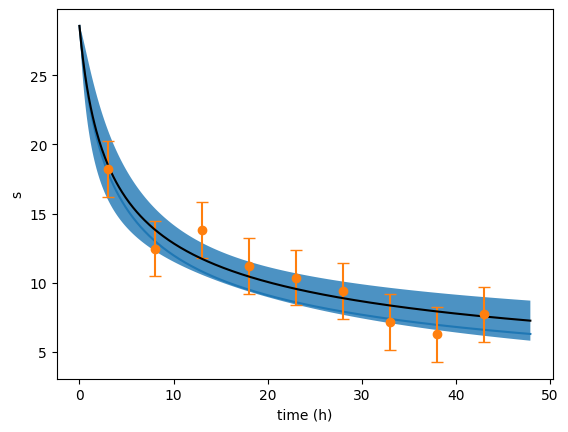

In [ ]:
theta = np.random.normal([30, -0.5], [10, 0.1])
print("theta = ", theta)
t_fit = np.arange(0, 48, 0.1)
y = power_law(t_fit, theta) 

plt.plot(t_fit, y)

t_data = np.arange(3, 48, 5)
y_data = power_law(t_data, theta) 
y_data = np.random.normal(y_data, scale=2)

plt.errorbar(t_data, y_data, yerr=2,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_data, y_data, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')
plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.8, label='95% confidence band')

plt.xlabel("time (h)")
plt.ylabel("s")

plt.show()

a = 31.806
b = -0.526


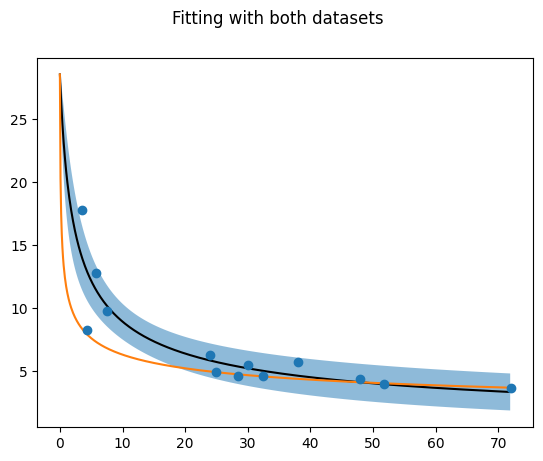

In [ ]:
# time points
t_data = np.array([3.5, 4.25, 5.75, 7.5, 24, 25, 28.5, 30, 32.5, 38, 48, 51.75, 72])

# mean of n samples at each time
y_mean = np.array([17.79526, 8.2668, 12.7622, 9.7465, 6.3022, 4.9254, 4.5688, 5.4894, 4.5752, 5.7354, (4.6958 + 4.0178) / 2, 3.9404, 3.6374])

plt.errorbar(t_data, y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_data, y_mean, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")


t_fit = np.arange(0, 72, 0.1)

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')

plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
plt.suptitle('Fitting with both datasets')

plt.show()

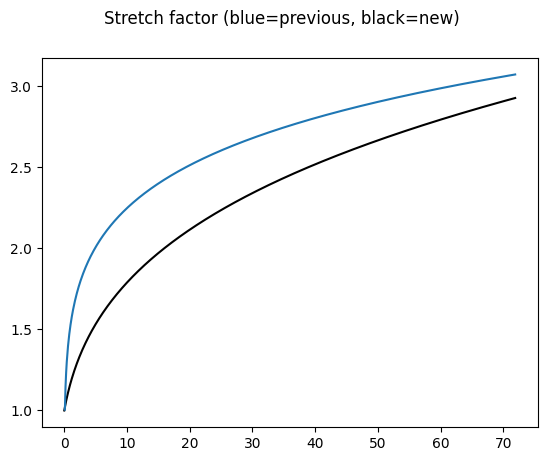

In [18]:
plt.plot(t_fit, 1 / np.sqrt(y_fit / 28.56), 'k-', label='Weighted fit')
plt.plot(t_fit[1:], 1 + (1 / np.sqrt(11.871 * t_fit[1:]**(-0.274) / 22.4696)-1) / 0.71)
plt.suptitle('Stretch factor (blue=previous, black=new)')

plt.show()

In [ ]:
t_0 = (28.56 / 31.8)**(-1/0.5255)
1 / np.sqrt(31.8 * (3.5 + t_0)**(-0.5255) / 28.56)

np.float64(1.425313686898639)

In [112]:
1 + (1 / np.sqrt(11.871 * 3.5**(-0.274) / 22.4696)-1) / 0.71


np.float64(1.8921062608728842)

a = 1.666
b = -0.649


/var/folders/xr/kfly1w_96s7_psdnnlq0mr3r0000gn/T/ipykernel_29049/551445220.py:2: RuntimeWarning: invalid value encountered in scalar power
  t_0 = (init_area / theta[0])**(1/theta[1])


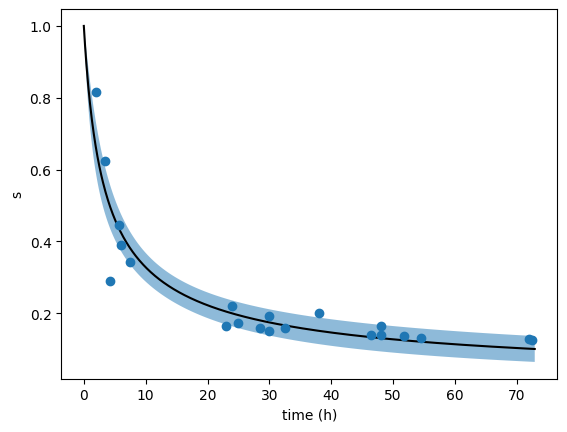

In [70]:
# time points
t_data = np.array([2, 3.5, 4.25, 5.75, 6, 7.5, 23, 24, 25, 28.5, 30, 30, 32.5, 38, 46.5, 48, 48, 51.75, 54.5, 72, 72.5])

# mean of n samples at each time
y_mean = np.array([0.815450477, 0.623624856, 0.289453782, 0.447244106, 0.389906471, 0.341560599, 0.165998802, 0.220857047, 0.172457983, 0.159971989, 0.192372929, 0.150282839, 0.160196078, 0.20099386, 0.138926138, 0.140679272, 0.164561664, 0.137969188, 0.131959661, 0.127359944, 0.126437505])

plt.errorbar(t_data, y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_data, y_mean, 1, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")


t_fit = np.arange(0, 73, 0.1)

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res, 1)

plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')

plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# plt.suptitle('Fitting with both datasets')

plt.xlabel("time (h)")
plt.ylabel("s")

plt.show()

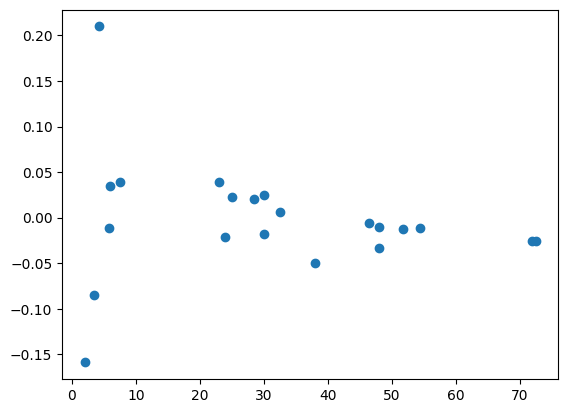

In [15]:
plt.errorbar(t_data, y_fit[(10 * t_data).astype(np.int64)] - y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)
plt.show()

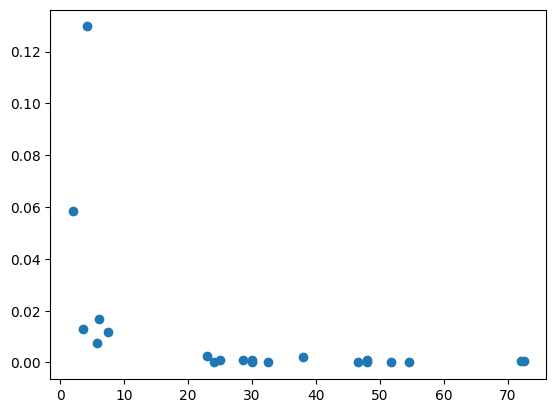

In [18]:
residuals = y_mean - power_law(t_data, optim_res.x)
plt.errorbar(t_data, residuals**2,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)
plt.show()

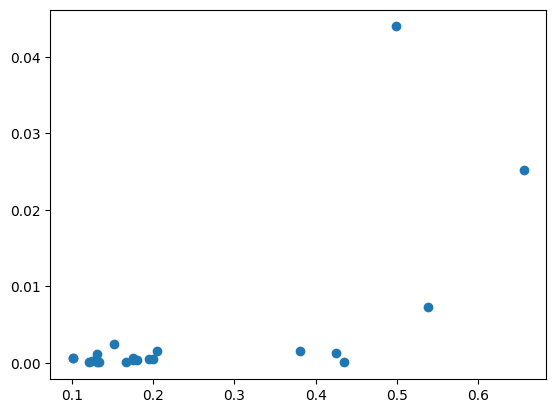

In [17]:
plt.errorbar(y_fit[(10 * t_data).astype(np.int64)], (y_fit[(10 * t_data).astype(np.int64)] - y_mean)**2,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)
plt.show()

a = 0.372
gamma = -1.983


[]

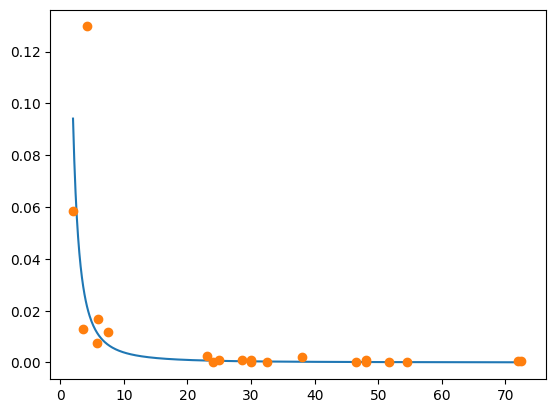

In [71]:
log_r2 = np.log(residuals**2)
log_t  = np.log(t_data)
gamma, alpha = np.polyfit(log_t, log_r2, 1)

print(f"a = {np.exp(alpha):.3f}")
print(f"gamma = {gamma:.3f}")

plt.plot(t_fit[20:], np.exp(alpha) * t_fit[20:]**gamma)
plt.errorbar(t_data, residuals**2,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)
plt.plot()

In [24]:
gamma

np.float64(-1.9828921611610972)

a = 0.778
b = -0.429


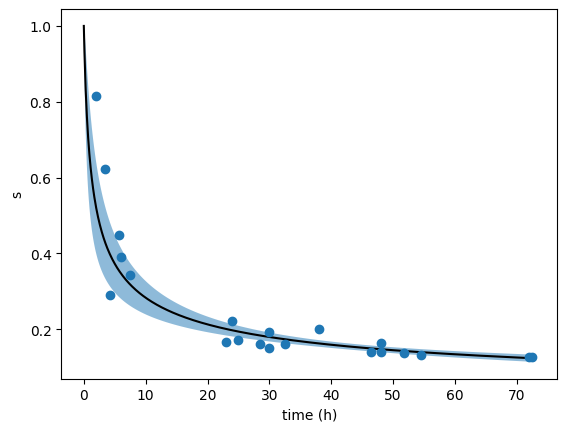

In [145]:
# time points
t_data = np.array([2, 3.5, 4.25, 5.75, 6, 7.5, 23, 24, 25, 28.5, 30, 30, 32.5, 38, 46.5, 48, 48, 51.75, 54.5, 72, 72.5])

# mean of n samples at each time
y_mean = np.array([0.815450477, 0.623624856, 0.289453782, 0.447244106, 0.389906471, 0.341560599, 0.165998802, 0.220857047, 0.172457983, 0.159971989, 0.192372929, 0.150282839, 0.160196078, 0.20099386, 0.138926138, 0.140679272, 0.164561664, 0.137969188, 0.131959661, 0.127359944, 0.126437505])

plt.errorbar(t_data, y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

W = 1 / t_data
optim_res = fitting(t_data, y_mean, W, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, 73, 0.1)

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res, 1)

y_fit = power_law(t_fit, optim_res.x, 1)
plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')

plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# plt.suptitle('Fitting with both datasets')

plt.xlabel("time (h)")
plt.ylabel("s")

plt.show()

a = 0.629
b = -0.375
a = 0.629
b = -0.375


/var/folders/xr/kfly1w_96s7_psdnnlq0mr3r0000gn/T/ipykernel_60701/3681206441.py:23: RuntimeWarning: invalid value encountered in scalar power
  t_0 = (1 / a)**(1/b)


NameError: name 'confidence_band2' is not defined

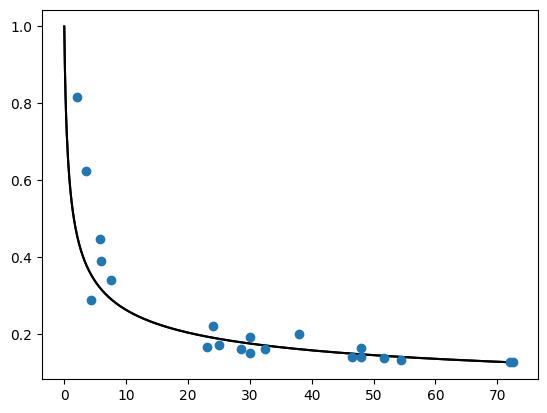

In [12]:
# time points
t_data = np.array([2, 3.5, 4.25, 5.75, 6, 7.5, 23, 24, 25, 28.5, 30, 30, 32.5, 38, 46.5, 48, 48, 51.75, 54.5, 72, 72.5])

# mean of n samples at each time
y_mean = np.array([0.815450477, 0.623624856, 0.289453782, 0.447244106, 0.389906471, 0.341560599, 0.165998802, 0.220857047, 0.172457983, 0.159971989, 0.192372929, 0.150282839, 0.160196078, 0.20099386, 0.138926138, 0.140679272, 0.164561664, 0.137969188, 0.131959661, 0.127359944, 0.126437505])

plt.errorbar(t_data, y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

W = (0.372 * t_data**(-2))
optim_res = fitting(t_data, y_mean, W, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, 73, 0.1)

plt.plot(t_fit, power_law(t_fit, optim_res.x, 1), 'k-', label='Weighted fit')

from scipy.optimize import curve_fit
def power_law2(t, a, b):
    t_0 = (1 / a)**(1/b)
    return a * (t + t_0)**b

popt, pcov, infodict, _, _ = curve_fit(
    power_law2,
    t_data,
    y_mean,
    sigma=W,
    p0=(12, -0.25),
    absolute_sigma=True,
    full_output=True
)

print(f"a = {popt[0]:.3f}")
print(f"b = {popt[1]:.3f}")

plt.plot(t_fit, power_law2(t_fit, popt[0], popt[1]), 'k-', label='Weighted fit')

n = len(optim_res.fun)
sigma_y = np.sqrt(np.sum((y_mean - power_law(t_data, optim_res.x))**2)) / (n - 2)

y, upperband, lowerband = confidence_band2(t_fit, popt, pcov, infodict['fvec'], 0, confprob=95, abswei=False)

# plt.fill_between(t_fit, lowerband, upperband,
#                  alpha=0.5, label='95% confidence band')

plt.plot(t_fit, power_law2(t_fit, 1.384, -0.5705))

plt.fill_between(t_fit, power_law2(t_fit, 1.268, -0.6938), power_law2(t_fit, 2.315, -0.5430),
                 alpha=0.5, label='95% confidence band')

plt.show()

In [188]:
def confidence_band2(t_fit, popt, pcov, fvec, err, confprob=95, abswei=False):
   #----------------------------------------------------------
   # Given a value for x, calculate the error df in y = model(p,x)
   # This function returns for each x in a NumPy array, the
   # upper and lower value of the confidence interval. 
   # The arrays with limits are returned and can be used to
   # plot confidence bands.  
   # 
   #
   # Input:
   #
   # x        NumPy array with values for which you want
   #          the confidence interval.
   #
   # dfdp     A list with derivatives. There are as many entries in
   #          this list as there are parameters in your model.
   #
   # confprob Confidence probability in percent (e.g. 90% or 95%).
   #          From this number we derive the confidence level 
   #          (e.g. 0.05). The Confidence Band
   #          is a 100*(1-alpha)% band. This implies
   #          that for a given value of x the probability that
   #          the 'true' value of f falls within these limits is
   #          100*(1-alpha)%.
   # 
   # fitobj   The Fitter object from a fit with kmpfit
   #
   # f        A function that returns a value y = f(p,x)
   #          p are the best-fit parameters and x is a NumPy array
   #          with values of x for which you want the confidence interval.
   #
   # abswei   Are the weights absolute? For absolute weights we take
   #          unscaled covariance matrix elements in our calculations.
   #          For unit weighting (i.e. unweighted) and relative 
   #          weighting, we scale the covariance matrix elements with 
   #          the value of the reduced chi squared.
   #
   # Returns:
   #
   # y          The model values at x: y = f(p,x)
   # upperband  The upper confidence limits
   # lowerband  The lower confidence limits   
   #
   # Note:
   #
   # If parameters were fixed in the fit, the corresponding 
   # error is 0 and there is no contribution to the condidence
   # interval.
   #----------------------------------------------------------   
   n = len(fvec)
   p = 2
   alpha = 1 - confprob/100.0
   tval = t.ppf(1 - alpha/2, n - 2)

   dfdp = power_law_gradient(t_fit, popt, 1)
   
   C = pcov
   N = len(t_fit)
   if abswei:
      covscale = 1.0
   else:
      covscale = np.sum(fvec**2) / (n - p)
   df2 = np.zeros(N)
   for j in range(p):
      for k in range(p):
         df2 += dfdp[:,j]*dfdp[:,k]*C[j,k]

   print(covscale * C)
   df = np.sqrt(err*err+covscale*df2)

   y = power_law(t_fit, popt, 1)
   delta = tval * df   
   upperband = y + delta
   lowerband = y - delta 
   return y, upperband, lowerband

In [7]:
import csv

def read_csv_to_array(filename):
    with open(filename, 'r', encoding='utf-8-sig') as f:
        reader = csv.reader(f)
        data = [list(map(float, row)) for row in reader]
    return np.array(data, dtype=np.float32)

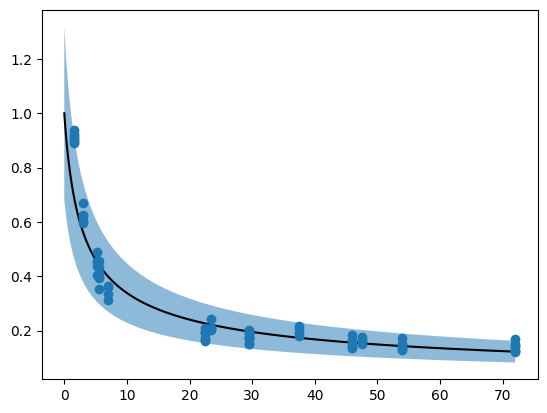

In [9]:
data = read_csv_to_array("data/area_prediction_intervals.csv")

x_data = data[:,0]
y_data = data[:,1]
y_lower = data[:,1] - data[:,2]
y_upper = data[:,1] + data[:,3]

data = read_csv_to_array("data/compaction_data.csv")

t_data = data[:,0]
y_mes = data[:,1]
plt.errorbar(t_data, y_mes,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

plt.plot(x_data, y_data, 'k-', label='Weighted fit')

# plt.plot(x_data, power_law2(x_data, 1.309, -0.5515), 'k-', label='Weighted fit')

plt.fill_between(x_data, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')

# optim_res = fitting(x_data, y_data, 1, 1)
# t_fit = t_fit = np.arange(0, 73, 0.1)
# plt.plot(t_fit, power_law(t_fit, optim_res.x, 1))

# print(f"a = {optim_res.x[0]:.3f}")
# print(f"b = {optim_res.x[1]:.3f}")

# optim_res = fitting(x_data, y_lower, 1, 1)
# plt.plot(t_fit, power_law(t_fit, optim_res.x, 1), 'k-')

# print(f"a = {optim_res.x[0]:.3f}")
# print(f"b = {optim_res.x[1]:.3f}")

# optim_res = fitting(x_data, y_upper, 1, 1)
# plt.plot(t_fit, power_law(t_fit, optim_res.x, 1), 'k-')

# print(f"a = {optim_res.x[0]:.3f}")
# print(f"b = {optim_res.x[1]:.3f}")
plt.savefig("uncertainty.pdf", dpi=75)
plt.show()

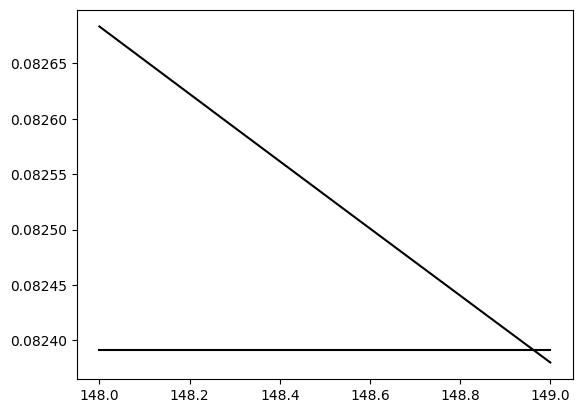

In [18]:
t_data = np.linspace(148, 149, 1000)
plt.plot(t_data, power_law2(t_data, 1.309, -0.5515), 'k-', label='Weighted fit')
plt.plot(t_data, 0.082391 * np.ones_like(t_data), 'k-', label='Weighted fit')

plt.show()

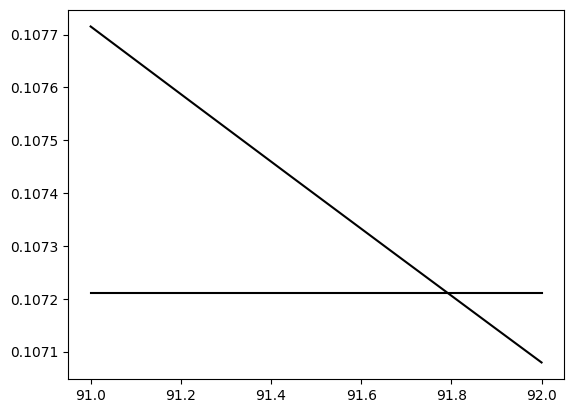

In [21]:
t_data = np.linspace(91, 92, 1000)
plt.plot(t_data, power_law2(t_data, 1.309, -0.5515), 'k-', label='Weighted fit')
plt.plot(t_data, 0.107210182 * np.ones_like(t_data), 'k-', label='Weighted fit')

plt.show()

In [26]:
a = np.linspace(1 / np.sqrt(0.122252901), 1 / np.sqrt(0.08239093), 1000, endpoint=False)
a[1] - a[0]

np.float64(0.0006238279707604377)

In [32]:
a = np.linspace(1 / np.sqrt(0.08239093), 1 / np.sqrt(0.06), 1000, endpoint=False)
a[1] - a[0]

np.float64(0.0005986260889394579)

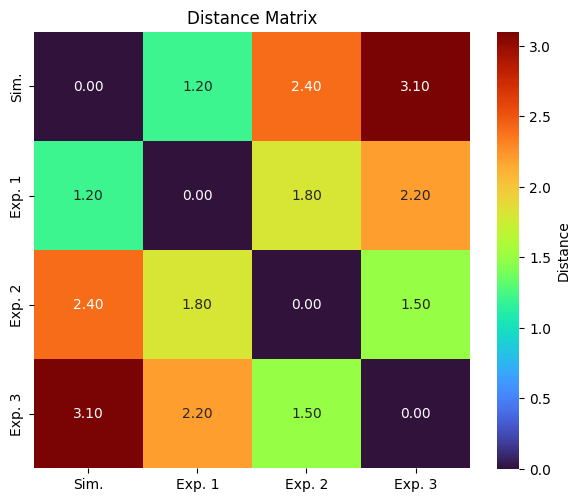

In [ ]:
labels = ["Sim.", "Exp. 1", "Exp. 2", "Exp. 3"]

D = np.array([
    [0.0, 1.2, 2.4, 3.1],
    [1.2, 0.0, 1.8, 2.2],
    [2.4, 1.8, 0.0, 1.5],
    [3.1, 2.2, 1.5, 0.0]
])

plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    D,
    annot=True,          # show numbers
    fmt=".2f",           # number format
    cmap="turbo",      # colormap
    xticklabels=labels,
    yticklabels=labels,
    square=True,
    cbar_kws={"label": "Distance"}
)

plt.title("Distance Matrix")
plt.tight_layout()
plt.show()
